In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

In [2]:
df_customers = pd.read_csv("Data\customers.csv")
df_loans = pd.read_csv("Data\loans.csv")
df_bureau = pd.read_csv(r"Data\bureau_data.csv")

In [3]:
[df.shape for df in [df_customers, df_loans, df_bureau]]

[(50000, 12), (50000, 15), (50000, 8)]

In [4]:
df = pd.merge(df_customers, df_loans, on='cust_id')
df = pd.merge(df, df_bureau)
print(df.shape)
df.head(2)

(50000, 33)


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,L00001,Auto,Secured,3004000,2467000,49340.0000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,L00002,Home,Secured,4161000,3883000,77660.0000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [6]:
df['default'] = df['default'].astype(int)
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [7]:
x = df.drop('default', axis=1)
y = df['default']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

df_train = pd.concat([x_train, y_train], axis='columns')
df_test = pd.concat([x_test, y_test], axis='columns')
# [df.shape for df in (df_train, df_test)]
[[df.shape for df in group] for group in ((df_train, df_test),
                                          (x_train, y_train), 
                                          (x_test, y_test))]

[[(37500, 33), (12500, 33)], [(37500, 32), (37500,)], [(12500, 32), (12500,)]]

In [8]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [9]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [10]:
mode_reridance = df_train.residence_type.mode()[0]
mode_reridance

'Owned'

In [11]:
df_train['residence_type'] = df_train['residence_type'].fillna(mode_reridance)

In [12]:
df_test['residence_type'] = df_test['residence_type'].fillna(mode_reridance)

In [13]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [14]:
[int(df.duplicated().sum()) for df in (df_train, df_test)]

[0, 0]

In [15]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [16]:
# continuous_cols = [col for col in df.columns
#                    if df[col].dtype != 'object'
#                    and df[col].nunique() > 2]

# categorical_cols = [col for col in df.columns
#                     if df[col].dtype == 'object'
#                     or df[col].nunique() <= 2]

In [17]:
col_continuous = ['age','income', 'number_of_dependants','years_at_current_address',
                  'sanction_amount', 'loan_amount',
                  'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
                  'principal_outstanding', 'bank_balance_at_application',
                  'number_of_open_accounts', 'number_of_closed_accounts',
                  'total_loan_months', 'delinquent_months', 'total_dpd',
                  'enquiry_count', 'credit_utilization_ratio']

col_categorical = ['gender', 'marital_status', 'employment_status', 
                   'residence_type', 'city', 'state', 'zipcode', 
                   'loan_purpose', 'loan_type', 'default']

In [18]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000,37500.0000
mean,39.5647,2636054.8267,1.9425,15.9940,418768.5733,4706706.5600,4002796.6400,80724.1088,720503.3952,3202237.3120,25.8966,1336077.1928,987467.4418,2.4965,0.9968,75.9997,4.8918,26.9361,5.0033,43.3278,0.0850
std,9.8542,2624140.9229,1.5358,8.9381,168831.8215,6288692.9399,5400902.4053,120830.6500,972162.4329,4320721.9242,12.4232,1213733.9276,1045108.5773,1.1172,0.8150,43.7057,5.8640,32.9255,2.0239,29.3550,0.2789
min,18.0000,0.0000,0.0000,1.0000,110001.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000,-1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000
25%,33.0000,803000.0000,0.0000,8.0000,302001.0000,1136000.0000,959000.0000,19180.0000,172620.0000,767200.0000,16.0000,423931.0000,286189.5000,1.0000,0.0000,42.0000,0.0000,0.0000,4.0000,18.0000,0.0000
50%,40.0000,1884000.0000,2.0000,16.0000,400001.0000,2651000.0000,2234000.0000,44700.0000,402120.0000,1787200.0000,24.0000,1000881.5000,666825.0000,2.0000,1.0000,71.0000,3.0000,14.0000,5.0000,39.0000,0.0000
75%,46.0000,3332000.0000,3.0000,24.0000,560001.0000,5159000.0000,4597250.0000,92000.0000,827505.0000,3677800.0000,35.0000,1789091.7500,1236740.5000,3.0000,2.0000,107.0000,9.0000,46.0000,6.0000,67.0000,0.0000
max,70.0000,11999000.0000,5.0000,31.0000,700001.0000,52175000.0000,47667000.0000,5698029.9008,8580060.0000,38133600.0000,59.0000,5000000.0000,7846643.0000,4.0000,2.0000,223.0000,24.0000,171.0000,9.0000,99.0000,1.0000


In [19]:
df_train.sample(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12820,C12821,54,M,Married,Self-Employed,3545000,3,Owned,22,Chennai,Tamil Nadu,600001,L12821,Home,Secured,10145000,7653000,153060.0000,1377540,6122400,45,2387499,1063238,2020-11-03,2020-12-01,4,2,122,0,0,8,58,0
22821,C22822,42,F,Single,Self-Employed,768000,0,Owned,31,Bangalore,Karnataka,560001,L22822,Personal,Unsecured,672000,574000,11480.0000,103320,459200,7,413279,273067,2021-11-03,2021-11-26,1,1,28,12,54,3,4,0


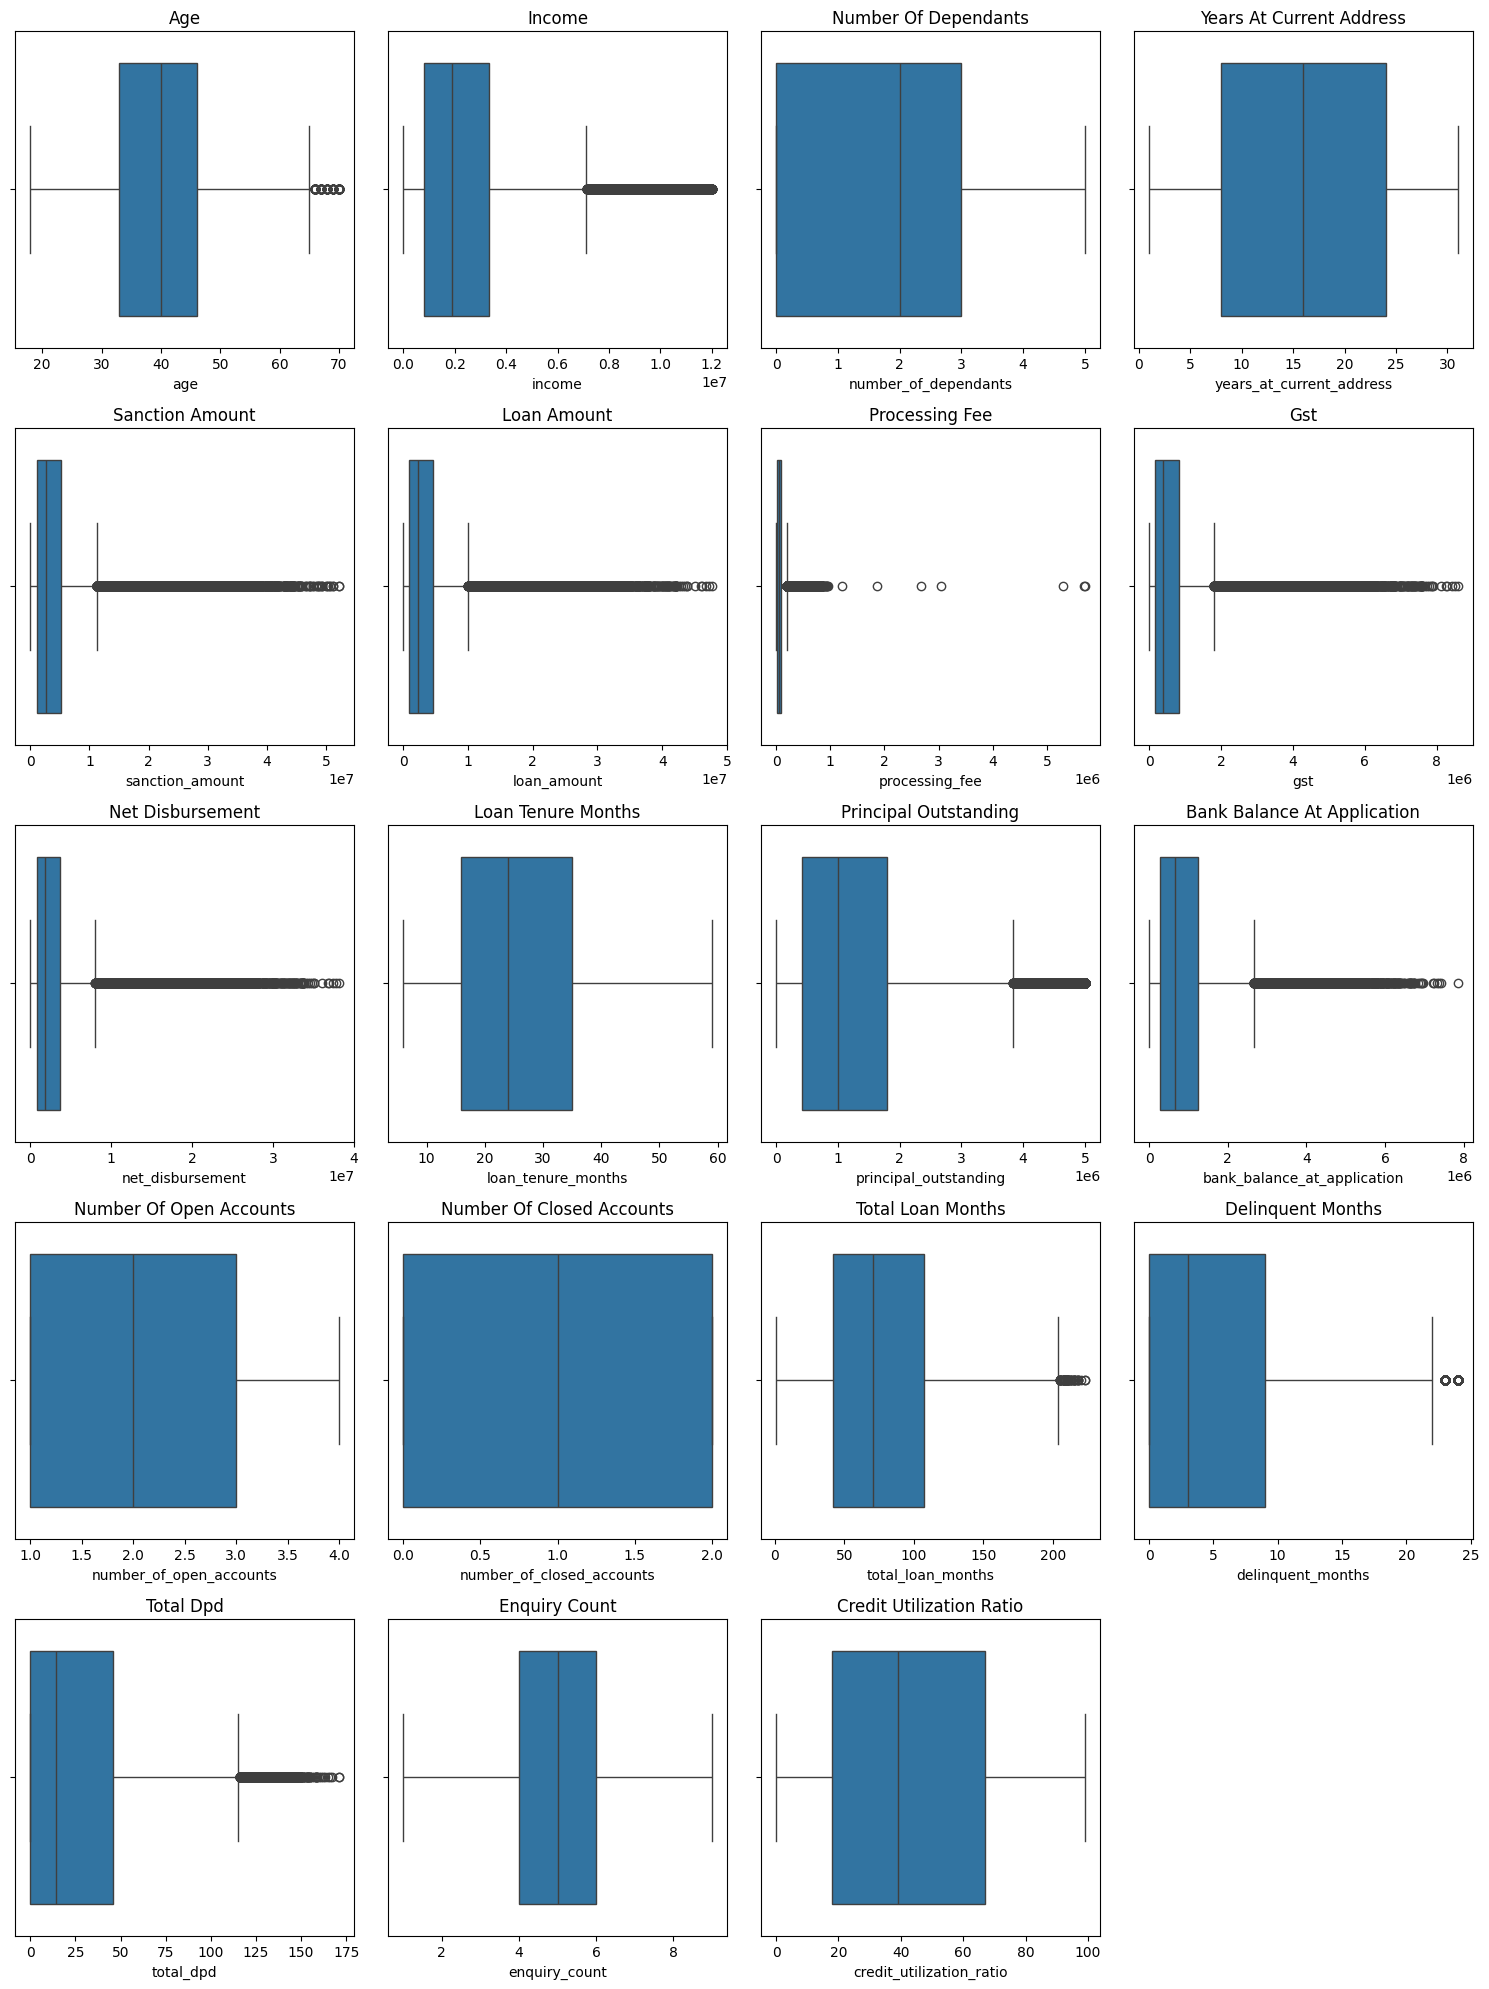

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 4  # number of columns in the grid
n_rows = math.ceil(len(col_continuous) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(col_continuous):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title())

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

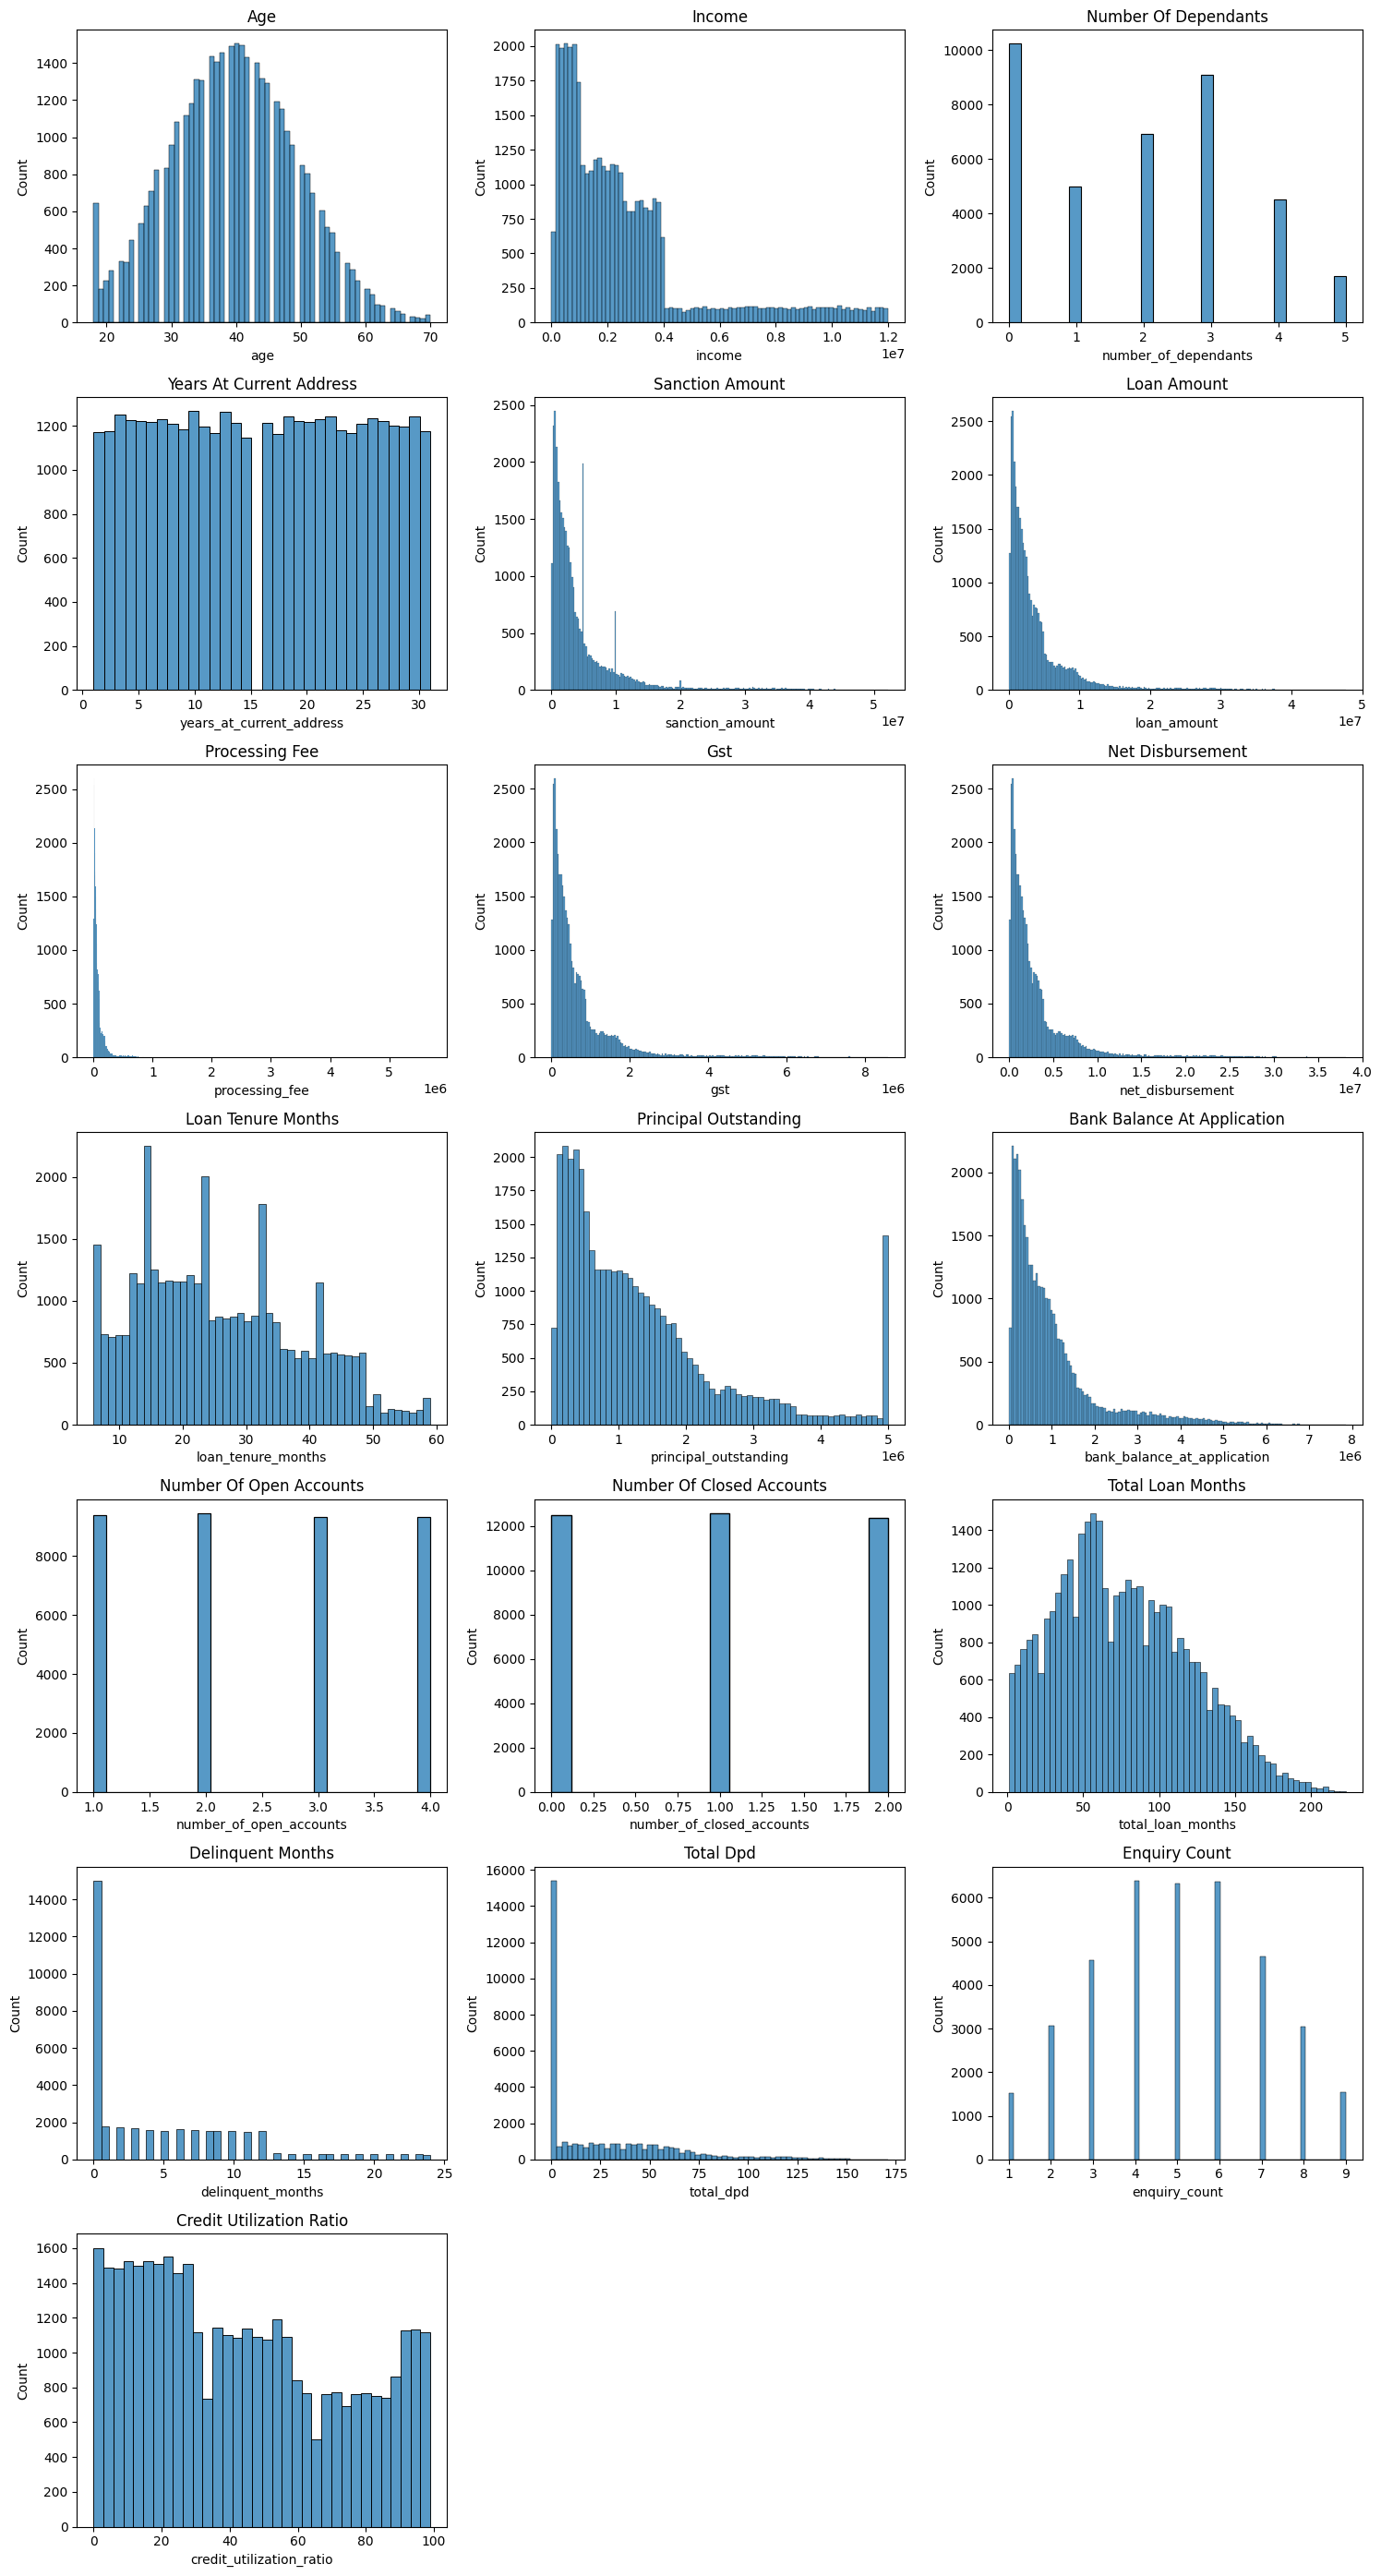

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3  # number of columns in the grid
n_rows = math.ceil(len(col_continuous) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(col_continuous):
    sns.histplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title())

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [22]:
df_train[['processing_fee', 'loan_amount']].describe()

,processing_fee,loan_amount
count,37500.0000,37500.0000
mean,80724.1088,4002796.6400
std,120830.6500,5400902.4053
min,0.0000,0.0000
25%,19180.0000,959000.0000
50%,44700.0000,2234000.0000
75%,92000.0000,4597250.0000
max,5698029.9008,47667000.0000


In [23]:
df_train_1 = df_train[(df_train['processing_fee'] / df_train['loan_amount']) < 0.03].copy()
df_train[(df_train['processing_fee'] / df_train['loan_amount']) > 0.03][['processing_fee', 'loan_amount']]

,processing_fee,loan_amount
23981,2669791.0231,2234000
9898,5293543.5242,3626000
47089,1858964.7679,1738000
33705,5678020.8590,3812000
12294,5698029.9008,4639000
28174,1214492.6731,966000
29305,3036378.0053,2616000


In [24]:
df_test = df_test[(df_test['processing_fee'] / df_test['loan_amount']) < 0.03].copy()

In [25]:
df_train_1.shape, df_test.shape

((37487, 33), (12498, 33))

In [26]:
col_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [27]:
for col in col_categorical:
    print(col, '-->', df_train_1[col].unique())

gender --> ['F' 'M']
marital_status --> ['Single' 'Married']
employment_status --> ['Salaried' 'Self-Employed']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state --> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
zipcode --> [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]
loan_purpose --> ['Home' 'Auto' 'Personal' 'Education' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
default --> [0 1]


In [28]:
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal', 'Personal')
df_test['loan_purpose'] = df_test['loan_purpose'].replace('Personaal', 'Personal')


In [29]:
for col in col_categorical:
    print(df_train_1[col].value_counts(normalize=True)*100)

gender
M   60.1889
F   39.8111
Name: proportion, dtype: float64
marital_status
Married   54.9124
Single    45.0876
Name: proportion, dtype: float64
employment_status
Self-Employed   64.4250
Salaried        35.5750
Name: proportion, dtype: float64
residence_type
Owned      56.4436
Mortgage   23.7362
Rented     19.8202
Name: proportion, dtype: float64
city
Jaipur      10.2756
Hyderabad   10.1102
Bangalore   10.1075
Mumbai      10.0782
Lucknow      9.9394
Delhi        9.9208
Pune         9.9181
Chennai      9.9021
Kolkata      9.8968
Ahmedabad    9.8514
Name: proportion, dtype: float64
state
Maharashtra     19.9963
Rajasthan       10.2756
Telangana       10.1102
Karnataka       10.1075
Uttar Pradesh    9.9394
Delhi            9.9208
Tamil Nadu       9.9021
West Bengal      9.8968
Gujarat          9.8514
Name: proportion, dtype: float64
zipcode
302001   10.2756
500001   10.1102
560001   10.1075
400001   10.0782
226001    9.9394
110001    9.9208
411001    9.9181
600001    9.9021
700001    9

In [30]:
for col in col_categorical:
    print(df_test[col].value_counts(normalize=True)*100)

gender
M   59.3455
F   40.6545
Name: proportion, dtype: float64
marital_status
Married   54.8488
Single    45.1512
Name: proportion, dtype: float64
employment_status
Self-Employed   64.1863
Salaried        35.8137
Name: proportion, dtype: float64
residence_type
Owned      57.0971
Mortgage   23.3477
Rented     19.5551
Name: proportion, dtype: float64
city
Kolkata     10.2976
Ahmedabad   10.2976
Chennai     10.0816
Mumbai      10.0336
Pune         9.9936
Jaipur       9.9536
Delhi        9.9216
Hyderabad    9.8576
Bangalore    9.7936
Lucknow      9.7696
Name: proportion, dtype: float64
state
Maharashtra     20.0272
West Bengal     10.2976
Gujarat         10.2976
Tamil Nadu      10.0816
Rajasthan        9.9536
Delhi            9.9216
Telangana        9.8576
Karnataka        9.7936
Uttar Pradesh    9.7696
Name: proportion, dtype: float64
zipcode
700001   10.2976
380001   10.2976
600001   10.0816
400001   10.0336
411001    9.9936
302001    9.9536
110001    9.9216
500001    9.8576
560001    9

<h1 align='center' style='color:yellow'>Exploratory Data Analysis</h1>

In [31]:
# sns.kdeplot(df_train_1[df_train_1.default == 0]['age'], fill=True, label='Default = 0')
# sns.kdeplot(df_train_1[df_train_1.default == 1]['age'], fill=True, label='Default = 1')
# plt.title('Age KDE Plot with Hue by default')
# plt.legend()
# plt.show()

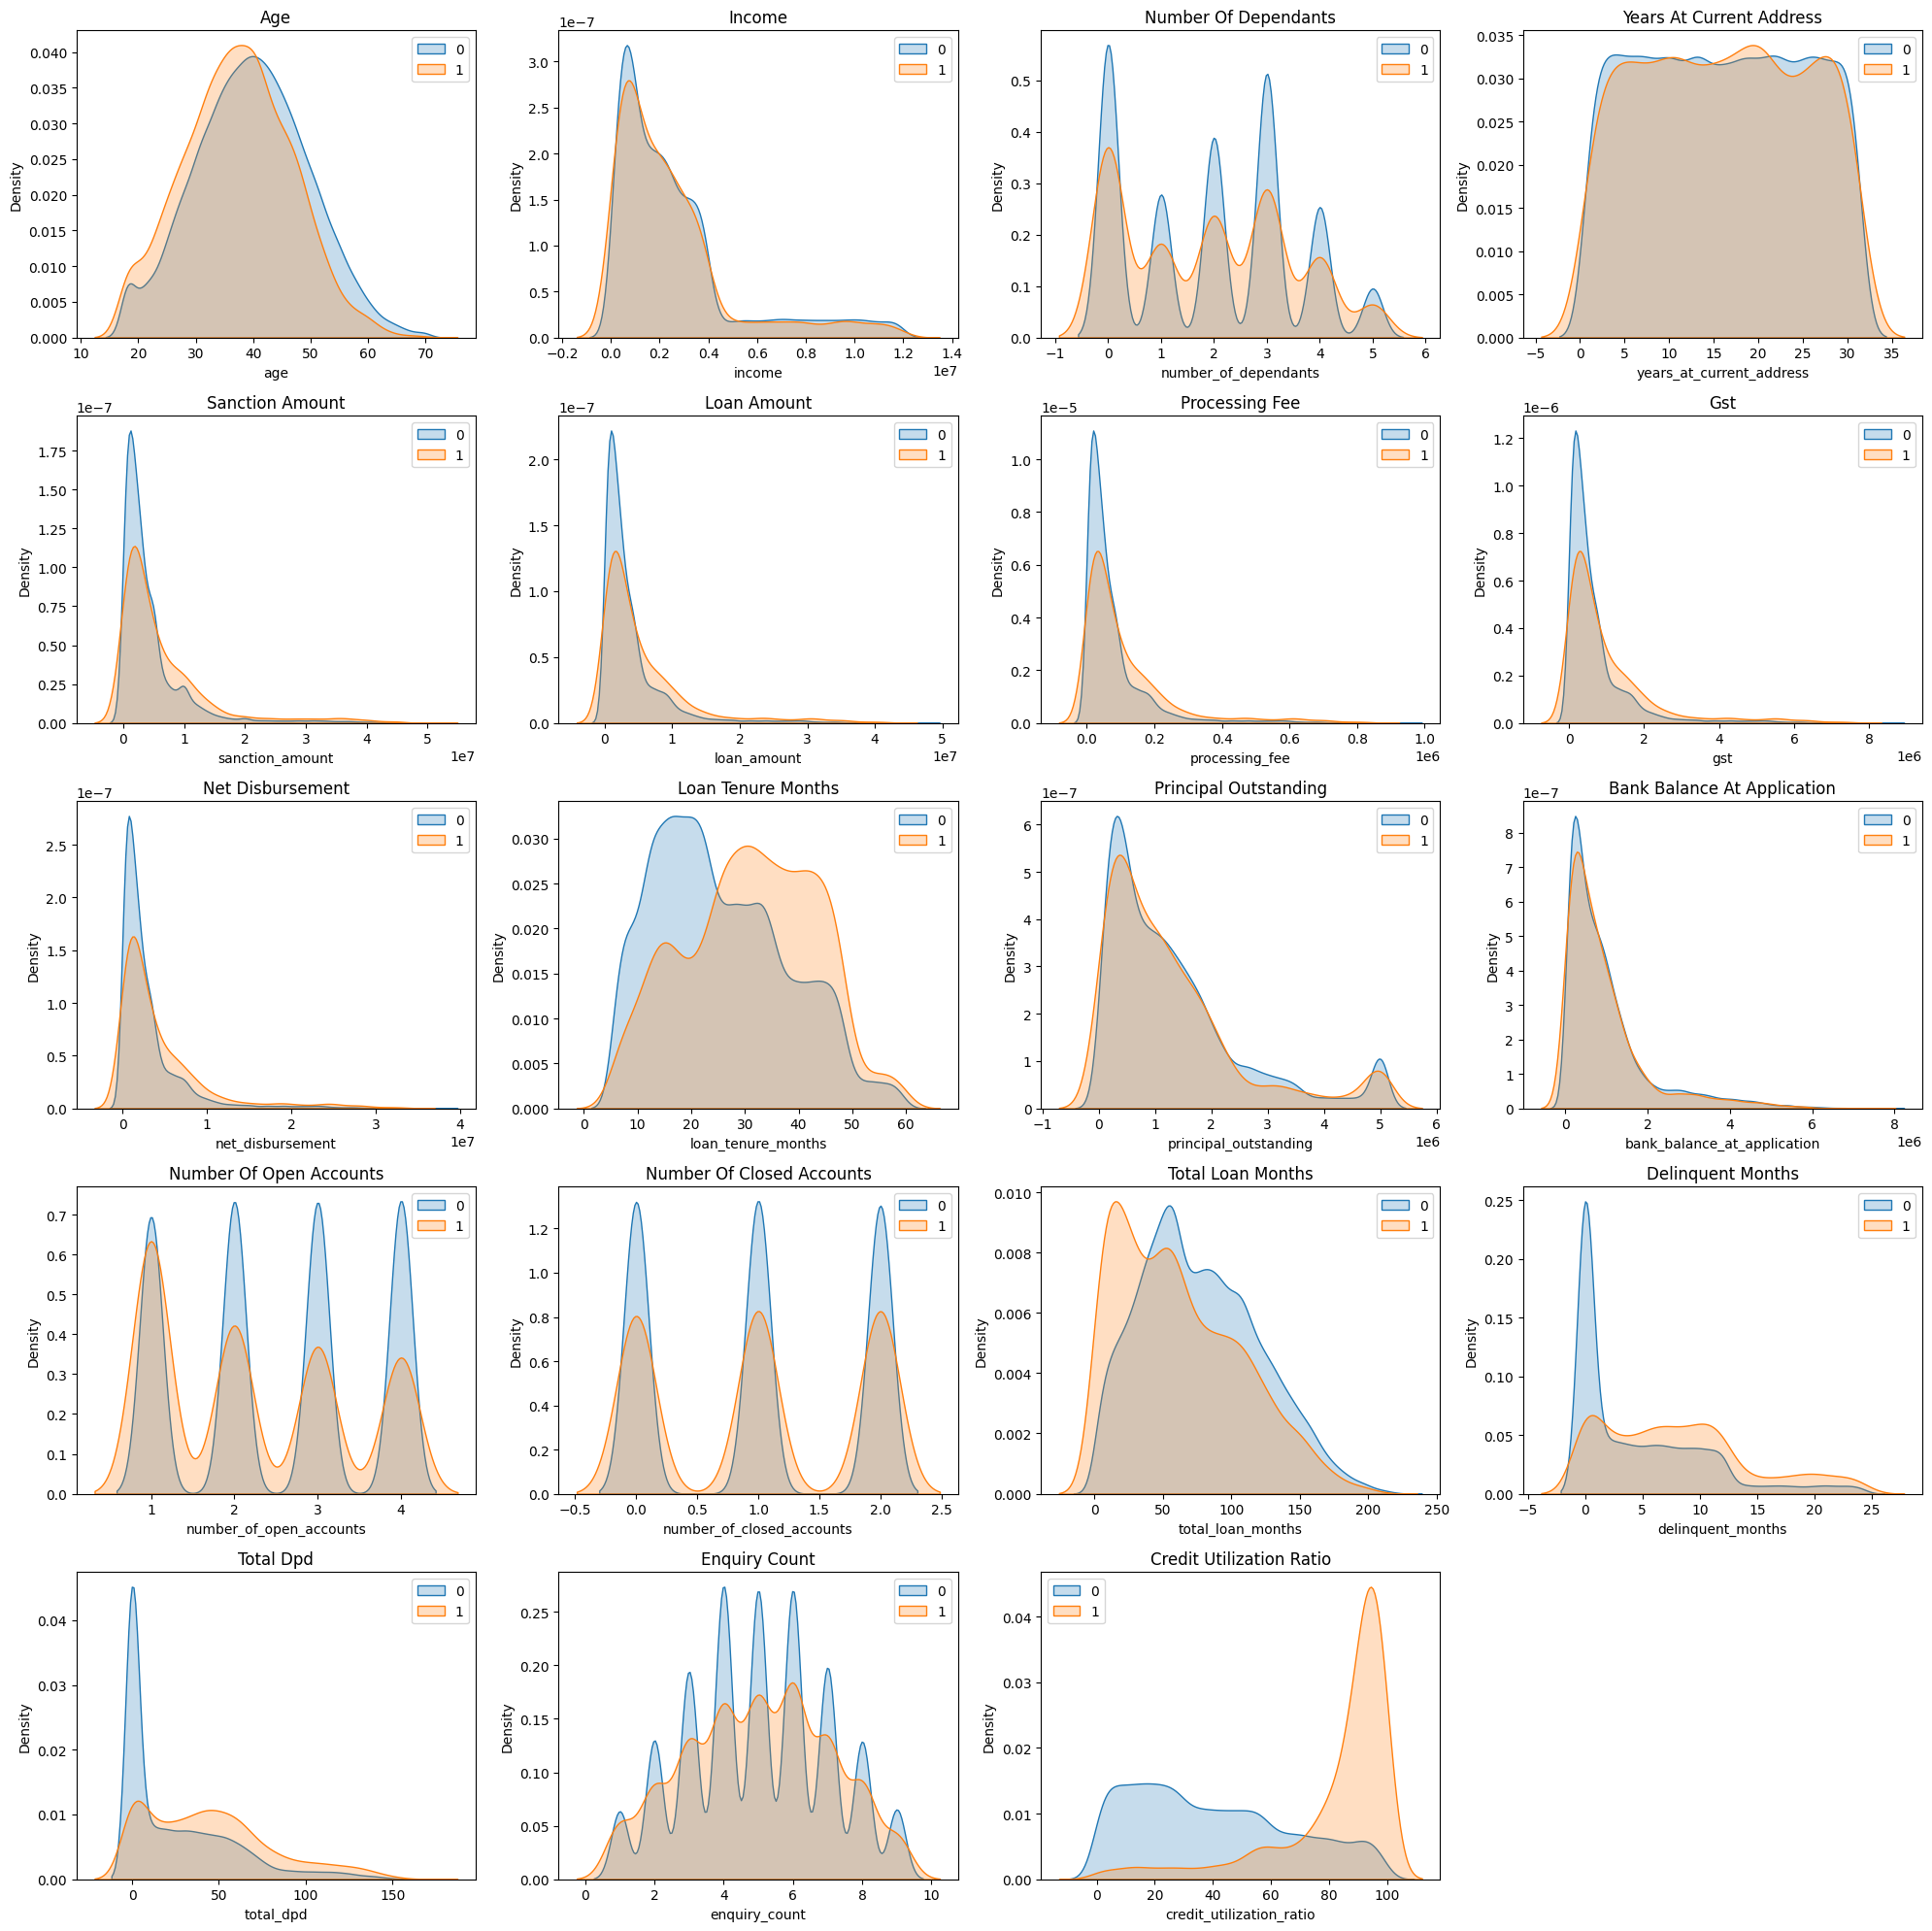

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 4  # Number of columns you want in the grid
n_rows = math.ceil(len(col_continuous) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(col_continuous, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.kdeplot(
        df_train_1[df_train_1['default'] == 0][col],
        fill=True, label='0'
    )

    sns.kdeplot(
        df_train_1[df_train_1['default'] == 1][col],
        fill=True, label='1'
    )

    plt.title(col.replace('_', ' ').title())
    plt.legend()

plt.tight_layout()
plt.show()

<h1 align='center' style='color:yellow'>Frature Engineering</h1>

In [33]:
df_train_1['loan_to_income'] = df_train_1['loan_amount'] / df_train_1['income']
df_test['loan_to_income'] = df_test['loan_amount'] / df_test['income']

df_train_1['loan_to_income'].describe()

count   37487.0000
mean        1.5549
std         0.9729
min         0.2962
25%         0.7696
50%         1.1561
75%         2.4542
max         4.5652
Name: loan_to_income, dtype: float64

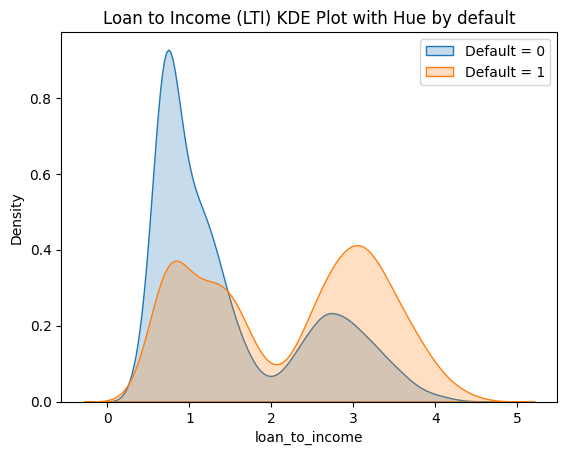

In [34]:
sns.kdeplot(df_train_1[df_train_1.default == 0]['loan_to_income'], fill=True, label='Default = 0')
sns.kdeplot(df_train_1[df_train_1.default == 1]['loan_to_income'], fill=True, label='Default = 1')
plt.title('Loan to Income (LTI) KDE Plot with Hue by default')
plt.legend()
plt.show()

In [35]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income'],
      dtype='object')

In [36]:
df_train_1['delinquency_ratio'] = df_train_1['delinquent_months'] * 100 / df_train_1['total_loan_months']
df_test['delinquency_ratio'] = df_test['delinquent_months'] * 100 / df_test['total_loan_months']

df_train_1['delinquency_ratio'].describe()

count   37487.0000
mean       10.3945
std        17.2685
min         0.0000
25%         0.0000
50%         3.7975
75%        13.1148
max       100.0000
Name: delinquency_ratio, dtype: float64

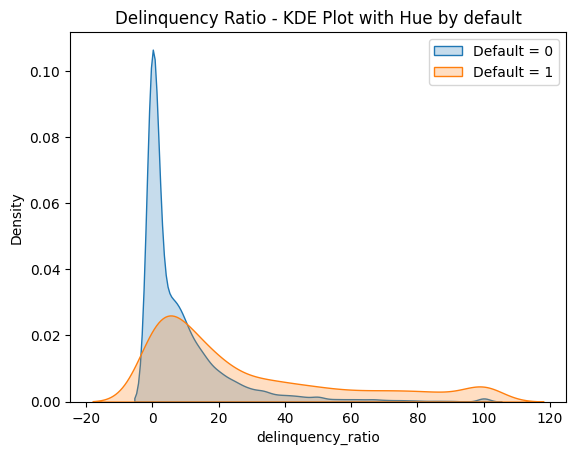

In [37]:
sns.kdeplot(df_train_1[df_train_1.default == 0]['delinquency_ratio'], fill=True, label='Default = 0')
sns.kdeplot(df_train_1[df_train_1.default == 1]['delinquency_ratio'], fill=True, label='Default = 1')
plt.title('Delinquency Ratio - KDE Plot with Hue by default')
plt.legend()
plt.show()

In [38]:
df_train_1['avg_dpd_per_delinquency'] = np.where(
    df_train_1['delinquent_months'] != 0,
    (df_train_1['total_dpd'] / df_train_1['delinquent_months']), 
    0)

df_test['avg_dpd_per_delinquency'] = np.where(
    df_test['delinquent_months'] != 0,
    (df_test['total_dpd'] / df_test['delinquent_months']), 
    0)

df_train_1['avg_dpd_per_delinquency'].describe()

count   37487.0000
mean        3.2946
std         2.9034
min         0.0000
25%         0.0000
50%         4.3333
75%         5.7500
max        10.0000
Name: avg_dpd_per_delinquency, dtype: float64

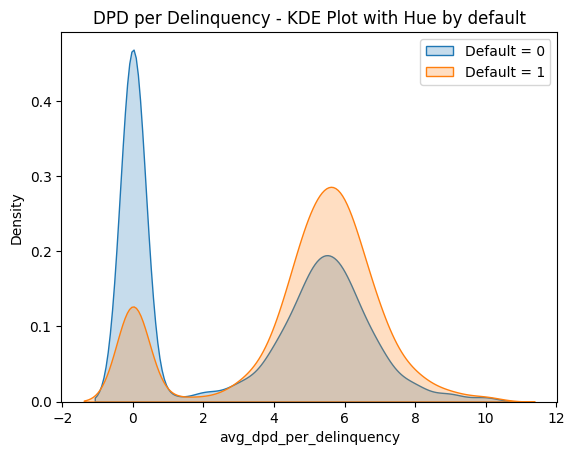

In [39]:
sns.kdeplot(df_train_1[df_train_1.default == 0]['avg_dpd_per_delinquency'], fill=True, label='Default = 0')
sns.kdeplot(df_train_1[df_train_1.default == 1]['avg_dpd_per_delinquency'], fill=True, label='Default = 1')
plt.title('DPD per Delinquency - KDE Plot with Hue by default')
plt.legend()
plt.show()

## Feature Selection

In [40]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [41]:
# Col deleated from techinical understanding

df_train_2 = df_train_1.drop(['cust_id', 'loan_id'], axis=1)
df_test = df_test.drop(['cust_id', 'loan_id'], axis=1)

In [42]:
# Col deleated from Bunsiness Understanding

df_train_3 = df_train_2.drop(['disbursal_date', 'installment_start_dt', 'loan_amount',
                             'income', 'total_loan_months', 'delinquent_months', 'total_dpd'], 
                             axis=1)

df_test = df_test.drop(['disbursal_date', 'installment_start_dt', 'loan_amount',
                             'income', 'total_loan_months', 'delinquent_months', 'total_dpd'], 
                             axis=1)

In [43]:
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [44]:
df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37487 entries, 27434 to 15795
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37487 non-null  int64  
 1   gender                       37487 non-null  object 
 2   marital_status               37487 non-null  object 
 3   employment_status            37487 non-null  object 
 4   number_of_dependants         37487 non-null  int64  
 5   residence_type               37487 non-null  object 
 6   years_at_current_address     37487 non-null  int64  
 7   city                         37487 non-null  object 
 8   state                        37487 non-null  object 
 9   zipcode                      37487 non-null  int64  
 10  loan_purpose                 37487 non-null  object 
 11  loan_type                    37487 non-null  object 
 12  sanction_amount              37487 non-null  int64  
 13  processing_fee   

In [45]:
df_train_3['default'] = df_train_3['default'].astype('int32')
df_test['default'] = df_test['default'].astype('int32')

In [46]:
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [47]:
X_train = df_train_3.drop('default', axis=1)
y_train = df_train_3['default']

from sklearn.preprocessing import MinMaxScaler

col_to_scale = df_train_3.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()
X_train[col_to_scale] = scaler.fit_transform(X_train[col_to_scale])

X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000,37487.0000
mean,0.4147,0.3885,0.4998,0.5233,0.0890,0.0830,0.0830,0.0830,0.3754,0.2619,0.1237,0.4988,0.4984,0.5004,0.4377,0.2948,0.1039,0.3295
std,0.1895,0.3072,0.2979,0.2862,0.1207,0.1134,0.1134,0.1134,0.2344,0.2445,0.1335,0.3724,0.4075,0.2530,0.2965,0.2279,0.1727,0.2903
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.2885,0.0000,0.2333,0.3254,0.0204,0.0191,0.0191,0.0191,0.1887,0.0782,0.0341,0.0000,0.0000,0.3750,0.1818,0.1109,0.0000,0.0000
50%,0.4231,0.4000,0.5000,0.4915,0.0495,0.0459,0.0459,0.0459,0.3396,0.1944,0.0827,0.3333,0.5000,0.5000,0.3939,0.2014,0.0380,0.4333
75%,0.5385,0.6000,0.7667,0.7627,0.0977,0.0955,0.0955,0.0955,0.5472,0.3532,0.1555,0.6667,1.0000,0.6250,0.6768,0.5055,0.1311,0.5750
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [48]:
X_test = df_test.drop('default', axis=1)
y_test = df_test['default']

X_test[col_to_scale] = scaler.transform(X_test[col_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000,12498.0000
mean,0.4137,0.3862,0.5031,0.5256,0.0888,0.0828,0.0828,0.0828,0.3787,0.2632,0.1245,0.5037,0.5070,0.5035,0.4390,0.2953,0.1041,0.3307
std,0.1890,0.3069,0.2964,0.2872,0.1191,0.1114,0.1114,0.1114,0.2351,0.2453,0.1340,0.3745,0.4056,0.2556,0.2966,0.2268,0.1740,0.2907
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0001,0.0001,0.0000,-0.0002,0.0002,0.0000,0.0000,0.0000,0.0000,0.0010,0.0000,0.0000
25%,0.2885,0.0000,0.2333,0.3254,0.0212,0.0197,0.0197,0.0197,0.1887,0.0789,0.0345,0.0000,0.0000,0.3750,0.1818,0.1115,0.0000,0.0000
50%,0.4231,0.4000,0.5000,0.5102,0.0499,0.0462,0.0462,0.0462,0.3585,0.1953,0.0836,0.6667,0.5000,0.5000,0.3939,0.2051,0.0377,0.4333
75%,0.5385,0.6000,0.7667,0.7627,0.0991,0.0967,0.0967,0.0967,0.5472,0.3546,0.1566,1.0000,1.0000,0.7500,0.6768,0.5052,0.1290,0.5747
max,1.0000,1.0000,1.0000,1.0000,0.9510,1.0032,1.0032,1.0032,1.0000,1.0000,0.8795,1.0000,1.0000,1.0000,1.0000,1.0061,1.0000,1.0000


In [49]:
from  statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [50]:
(calculate_vif(X_train[col_to_scale]))

C:\Users\Adarsh\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Columns,VIF
0,age,5.7171
1,number_of_dependants,2.7317
2,years_at_current_address,3.4247
3,zipcode,3.7937
4,sanction_amount,102.1548
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.1426
9,principal_outstanding,16.2794


In [51]:
# After droping multiple features multiple time I confirm my understanding 
# to drop following features at once

features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 
                        'net_disbursement', 'principal_outstanding']

X_train_1 = X_train.drop(features_to_drop_vif, axis=1)

num_col = X_train_1.select_dtypes(['int64', 'float64']).columns
num_col

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [52]:
vif_df = calculate_vif(X_train_1[num_col])
vif_df

,Columns,VIF
0,age,5.4451
1,number_of_dependants,2.7282
2,years_at_current_address,3.4081
3,zipcode,3.7716
4,loan_tenure_months,5.9842
5,bank_balance_at_application,1.8013
6,number_of_open_accounts,4.3210
7,number_of_closed_accounts,2.3510
8,enquiry_count,6.3673
9,credit_utilization_ratio,2.9161


In [53]:
select_numeric_features_vif = vif_df.Columns.values
select_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'], dtype=object)

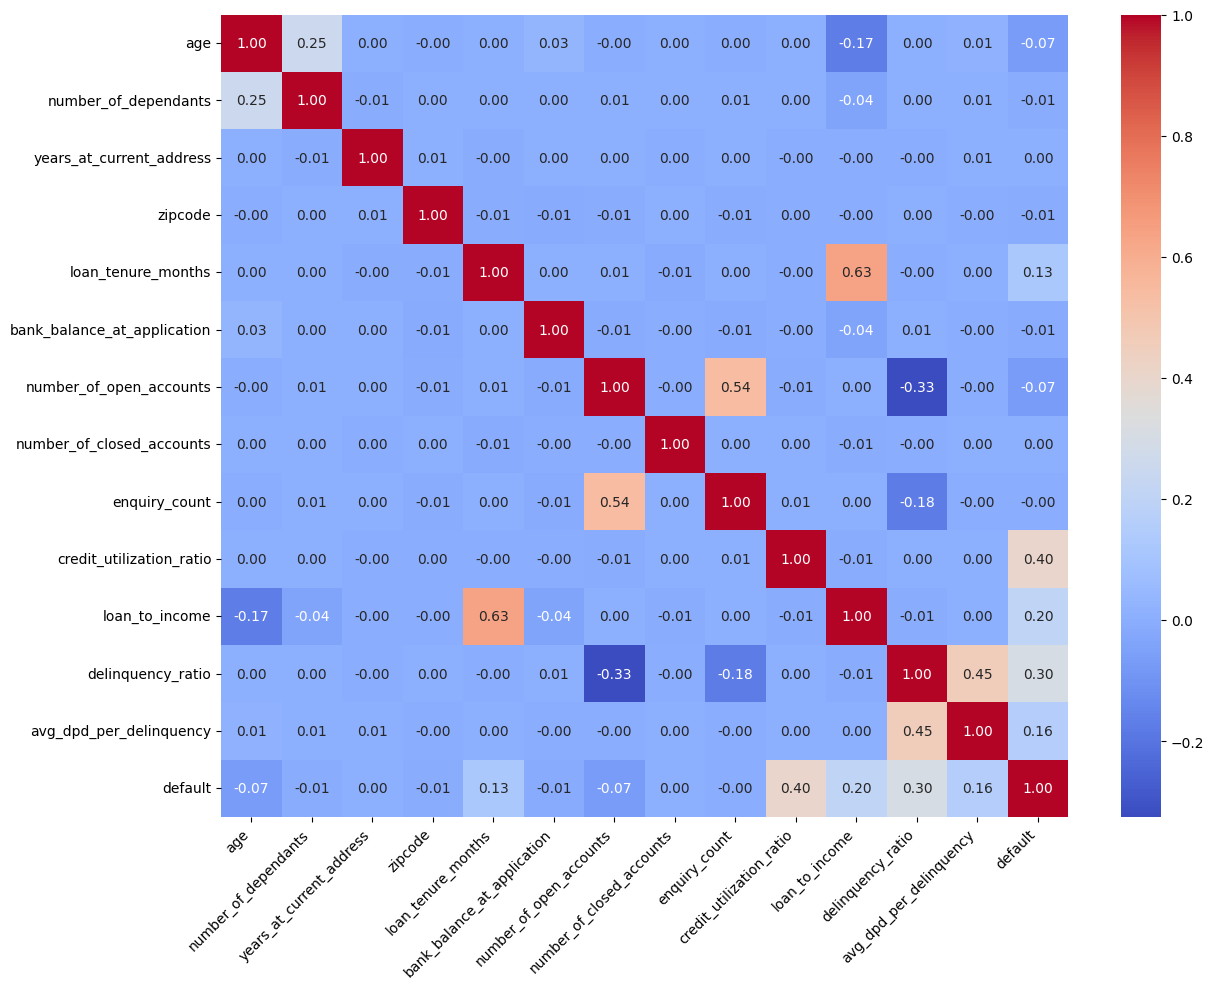

In [54]:
plt.figure(figsize=(13,10))
cm = df_train_3[num_col.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
col_categorical

['gender',
 'marital_status',
 'employment_status',
 'residence_type',
 'city',
 'state',
 'zipcode',
 'loan_purpose',
 'loan_type',
 'default']

In [56]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns = {'count': 'total', 'sum': 'good'})
    grouped['bad'] = grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad

    grouped['woe'] = np.log(grouped['good_pct']/grouped['bad_pct'])

    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)

    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), 'loan_purpose', 'default')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,
Auto,7437,314,7123,0.0985,0.2077,-0.7463,0.0815
Education,5626,546,5080,0.1712,0.1481,0.1449,0.0033
Home,11271,1744,9527,0.5469,0.2778,0.6774,0.1823
Personal,13153,585,12568,0.1834,0.3664,-0.6919,0.1266


In [57]:
iv_values = {}

for feature in X_train_1.columns: 
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), feature, 'default')
        
    else:
        x_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([x_binned, y_train], axis=1), feature, 'default')
        
    iv_values[feature] = iv

pd.Series(iv_values).sort_values(ascending=False)

credit_utilization_ratio      2.4228
delinquency_ratio             0.6783
loan_to_income                0.4917
avg_dpd_per_delinquency       0.4212
loan_purpose                  0.3938
residence_type                0.2594
loan_tenure_months            0.2345
loan_type                     0.1730
age                           0.0759
number_of_open_accounts       0.0732
enquiry_count                 0.0055
bank_balance_at_application   0.0042
number_of_dependants          0.0036
employment_status             0.0024
marital_status                0.0022
years_at_current_address      0.0010
city                          0.0008
state                         0.0008
zipcode                       0.0007
gender                        0.0005
number_of_closed_accounts     0.0003
dtype: float64

In [58]:
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.4228
19,delinquency_ratio,0.6783
18,loan_to_income,0.4917
20,avg_dpd_per_delinquency,0.4212
10,loan_purpose,0.3938
5,residence_type,0.2594
12,loan_tenure_months,0.2345
11,loan_type,0.1730
0,age,0.0759
14,number_of_open_accounts,0.0732


In [59]:
selected_feature_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_feature_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

## Feature Encoding

In [60]:
X_train_requced = X_train_1[selected_feature_iv]
X_test_reduced = X_test[selected_feature_iv]

In [61]:
X_train_encoded = pd.get_dummies(X_train_requced, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)


In [62]:
X_train_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
27434,0.5192,0.3396,1.0000,0.5960,0.6091,0.0667,0.5500,True,False,False,True,False,False
13400,0.2115,0.5094,0.6667,0.9293,0.1846,0.0336,0.4250,True,False,False,False,False,False
883,0.6154,0.2453,0.3333,0.8384,0.0862,0.1687,0.5571,False,False,False,False,True,True
7303,0.4808,0.2830,0.0000,0.3434,0.1873,0.0000,0.0000,True,False,False,False,False,False
45124,0.2500,0.7358,0.3333,0.1919,0.3626,0.0968,0.4667,True,False,True,False,False,False


<h1 align="center" style="color: yellow;">Model Training</h1>

### Attemp 1
1. Logistic Regression, RandomForest & XGB
2. No handling of class imbalance

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [65]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



#### RandomizedSearch CV for Attempt 1: Logistic Regression

In [66]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'lbfgs', 'C': np.float64(545.5594781168514)}
Best Score: 0.7629892080748256
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.83      0.71      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.85      0.87     12498
weighted avg       0.96      0.96      0.96     12498



#### RandomizedSearch CV for Attempt 1: XGBoost

In [67]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Score: 0.7925496419880317
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11390
           1       0.78      0.81      0.79      1108

    accuracy                           0.96     12498
   macro avg       0.88      0.90      0.89     12498
weighted avg       0.96      0.96      0.96     12498



### Attempt 2

1. Logistic Regression & XGB
1. Handle Class Imbalance Using Under Sampling

In [68]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_encoded, y_train)
y_train_res.value_counts()

default
0    3189
1    3189
Name: count, dtype: int64

In [69]:
model = LogisticRegression()
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11390
           1       0.53      0.95      0.68      1108

    accuracy                           0.92     12498
   macro avg       0.76      0.93      0.82     12498
weighted avg       0.95      0.92      0.93     12498



In [70]:
model = XGBClassifier(**random_search.best_params_)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11390
           1       0.51      0.98      0.67      1108

    accuracy                           0.92     12498
   macro avg       0.76      0.94      0.81     12498
weighted avg       0.95      0.92      0.93     12498



### Attempt 3

1. Logistic Regression
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [71]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34226
1    34226
Name: count, dtype: int64

In [72]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [73]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [74]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-06-18 19:50:29,855] A new study created in memory with name: no-name-6084ff21-74a1-4990-acce-28c067fb1fa2
[I 2026-06-18 19:50:30,115] Trial 0 finished with value: 0.942980145988567 and parameters: {'C': 9005.517474648033, 'solver': 'liblinear', 'tol': 0.05683322680749869, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.942980145988567.
[I 2026-06-18 19:50:30,524] Trial 1 finished with value: 0.9448225675135543 and parameters: {'C': 2.9059642582857914, 'solver': 'saga', 'tol': 0.00012139536678462134, 'class_weight': None}. Best is trial 1 with value: 0.9448225675135543.
[I 2026-06-18 19:50:31,030] Trial 2 finished with value: 0.9356621465760379 and parameters: {'C': 0.03341346012907068, 'solver': 'saga', 'tol': 2.4956659914385825e-05, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9448225675135543.
[I 2026-06-18 19:50:31,329] Trial 3 finished with value: 0.9229784204199699 and parameters: {'C': 0.013202127276876084, 'solver': 'liblinear', 'tol': 0.00011883

In [75]:
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9448814814468461
  Params: 
    C: 4.989180482646039
    solver: saga
    tol: 8.35199743902708e-05
    class_weight: None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



### Attempt 4

1. XGBoost
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [76]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-06-18 19:50:50,030] A new study created in memory with name: no-name-0d748625-f7aa-4791-b9ae-b0029b3ee8e0
[I 2026-06-18 19:50:51,501] Trial 0 finished with value: 0.960792790878326 and parameters: {'lambda': 4.941480993548648, 'alpha': 0.005633670455801764, 'subsample': 0.7330149649212628, 'colsample_bytree': 0.43278106003983796, 'max_depth': 6, 'eta': 0.12420243603138695, 'gamma': 9.437489545658384, 'scale_pos_weight': 1.6812763949953848, 'min_child_weight': 8, 'max_delta_step': 9}. Best is trial 0 with value: 0.960792790878326.
[I 2026-06-18 19:50:53,054] Trial 1 finished with value: 0.9310108114957102 and parameters: {'lambda': 0.17991194849577155, 'alpha': 0.1808389675525393, 'subsample': 0.530130308282992, 'colsample_bytree': 0.41493766112037433, 'max_depth': 9, 'eta': 0.04418930282306149, 'gamma': 8.445078058616943, 'scale_pos_weight': 3.4781770437198434, 'min_child_weight': 8, 'max_delta_step': 5}. Best is trial 0 with value: 0.960792790878326.
[I 2026-06-18 19:50:54,373

In [77]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9736326345235199
  Params: 
    lambda: 0.007370973236490219
    alpha: 0.12120265454292915
    subsample: 0.5096127537633975
    colsample_bytree: 0.892126412872343
    max_depth: 10
    eta: 0.18936100089204552
    gamma: 1.2017170679143465
    scale_pos_weight: 9.082475435594045
    min_child_weight: 5
    max_delta_step: 4
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     11390
           1       0.67      0.89      0.76      1108

    accuracy                           0.95     12498
   macro avg       0.83      0.93      0.87     12498
weighted avg       0.96      0.95      0.95     12498



## Model Evaluation : ROC/AUC

In [78]:
y_pred = best_model_logistic.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [79]:
from sklearn.metrics import roc_curve

probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.       , 0.       , 0.       , 0.0000878, 0.0000878]),
 array([0.        , 0.00090253, 0.20938628, 0.20938628, 0.22472924]),
 array([       inf, 0.99999994, 0.99879648, 0.99878967, 0.99856647]))

In [80]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9829798765780358

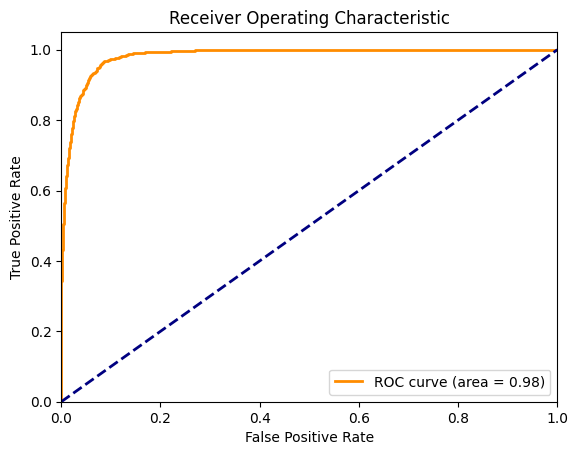

In [81]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Model Evaluation : Rankordering, KS statistic, Gini coeff

In [82]:
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]

df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})
df_eval.head(3)

,Default Truth,Default Probability
33553,0,0.0000
9427,0,0.7666
199,0,0.1384


In [83]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
df_eval.head(3)

,Default Truth,Default Probability,Decile
33553,0,0.0000,1
9427,0,0.7666,8
199,0,0.1384,7


In [84]:
df_eval[df_eval.Decile==8]['Default Probability'].describe()

count   1250.0000
mean       0.4924
std        0.1858
min        0.2074
25%        0.3268
50%        0.4776
75%        0.6592
max        0.8205
Name: Default Probability, dtype: float64

In [85]:
df_decile = df_eval.groupby('Decile').apply(
    lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(), 
}))
df_decile.reset_index(inplace=True)
df_decile

C:\Users\Adarsh\AppData\Local\Temp\ipykernel_15912\406936658.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_decile = df_eval.groupby('Decile').apply(


,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.0000,0.0000,0.0000,1250.0000
1,1,0.0000,0.0000,0.0000,1250.0000
2,2,0.0000,0.0000,0.0000,1250.0000
3,3,0.0000,0.0002,0.0000,1249.0000
4,4,0.0002,0.0009,0.0000,1250.0000
5,5,0.0009,0.0051,1.0000,1249.0000
6,6,0.0051,0.0322,2.0000,1247.0000
7,7,0.0322,0.2072,17.0000,1233.0000
8,8,0.2074,0.8205,168.0000,1082.0000
9,9,0.8206,1.0000,920.0000,330.0000


In [87]:
df_decile['Event Rate'] = df_decile['Events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile['Non-event Rate'] = df_decile['Non-events']*100 / (df_decile['Events']+df_decile['Non-events'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.8206,1.0000,920.0000,330.0000,73.6000,26.4000
1,8,0.2074,0.8205,168.0000,1082.0000,13.4400,86.5600
2,7,0.0322,0.2072,17.0000,1233.0000,1.3600,98.6400
3,6,0.0051,0.0322,2.0000,1247.0000,0.1601,99.8399
4,5,0.0009,0.0051,1.0000,1249.0000,0.0800,99.9200
5,4,0.0002,0.0009,0.0000,1250.0000,0.0000,100.0000
6,3,0.0000,0.0002,0.0000,1249.0000,0.0000,100.0000
7,2,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000
8,1,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000
9,0,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000


In [88]:
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.8206,1.0000,920.0000,330.0000,73.6000,26.4000
1,8,0.2074,0.8205,168.0000,1082.0000,13.4400,86.5600
2,7,0.0322,0.2072,17.0000,1233.0000,1.3600,98.6400
3,6,0.0051,0.0322,2.0000,1247.0000,0.1601,99.8399
4,5,0.0009,0.0051,1.0000,1249.0000,0.0800,99.9200
5,4,0.0002,0.0009,0.0000,1250.0000,0.0000,100.0000
6,3,0.0000,0.0002,0.0000,1249.0000,0.0000,100.0000
7,2,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000
8,1,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000
9,0,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000


In [89]:
df_decile['Cum Events'] =  df_decile['Events'].cumsum()
df_decile['Cum Non-events'] =  df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.8206,1.0000,920.0000,330.0000,73.6000,26.4000,920.0000,330.0000
1,8,0.2074,0.8205,168.0000,1082.0000,13.4400,86.5600,1088.0000,1412.0000
2,7,0.0322,0.2072,17.0000,1233.0000,1.3600,98.6400,1105.0000,2645.0000
3,6,0.0051,0.0322,2.0000,1247.0000,0.1601,99.8399,1107.0000,3892.0000
4,5,0.0009,0.0051,1.0000,1249.0000,0.0800,99.9200,1108.0000,5141.0000
5,4,0.0002,0.0009,0.0000,1250.0000,0.0000,100.0000,1108.0000,6391.0000
6,3,0.0000,0.0002,0.0000,1249.0000,0.0000,100.0000,1108.0000,7640.0000
7,2,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,8890.0000
8,1,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,10140.0000
9,0,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,11390.0000


In [90]:
df_decile['Cum Event Rate'] = df_decile['Cum Events'] * 100 / df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = df_decile['Cum Non-events']*100 / df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.8206,1.0000,920.0000,330.0000,73.6000,26.4000,920.0000,330.0000,83.0325,2.8973
1,8,0.2074,0.8205,168.0000,1082.0000,13.4400,86.5600,1088.0000,1412.0000,98.1949,12.3968
2,7,0.0322,0.2072,17.0000,1233.0000,1.3600,98.6400,1105.0000,2645.0000,99.7292,23.2221
3,6,0.0051,0.0322,2.0000,1247.0000,0.1601,99.8399,1107.0000,3892.0000,99.9097,34.1703
4,5,0.0009,0.0051,1.0000,1249.0000,0.0800,99.9200,1108.0000,5141.0000,100.0000,45.1361
5,4,0.0002,0.0009,0.0000,1250.0000,0.0000,100.0000,1108.0000,6391.0000,100.0000,56.1106
6,3,0.0000,0.0002,0.0000,1249.0000,0.0000,100.0000,1108.0000,7640.0000,100.0000,67.0764
7,2,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,8890.0000,100.0000,78.0509
8,1,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,10140.0000,100.0000,89.0255
9,0,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,11390.0000,100.0000,100.0000


In [91]:
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.8206,1.0000,920.0000,330.0000,73.6000,26.4000,920.0000,330.0000,83.0325,2.8973,80.1352
1,8,0.2074,0.8205,168.0000,1082.0000,13.4400,86.5600,1088.0000,1412.0000,98.1949,12.3968,85.7981
2,7,0.0322,0.2072,17.0000,1233.0000,1.3600,98.6400,1105.0000,2645.0000,99.7292,23.2221,76.5071
3,6,0.0051,0.0322,2.0000,1247.0000,0.1601,99.8399,1107.0000,3892.0000,99.9097,34.1703,65.7394
4,5,0.0009,0.0051,1.0000,1249.0000,0.0800,99.9200,1108.0000,5141.0000,100.0000,45.1361,54.8639
5,4,0.0002,0.0009,0.0000,1250.0000,0.0000,100.0000,1108.0000,6391.0000,100.0000,56.1106,43.8894
6,3,0.0000,0.0002,0.0000,1249.0000,0.0000,100.0000,1108.0000,7640.0000,100.0000,67.0764,32.9236
7,2,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,8890.0000,100.0000,78.0509,21.9491
8,1,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,10140.0000,100.0000,89.0255,10.9745
9,0,0.0000,0.0000,0.0000,1250.0000,0.0000,100.0000,1108.0000,11390.0000,100.0000,100.0000,0.0000


To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).

**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (If KS is in top 3 decile and score above 40, it is considered a good predictive model.)

In [92]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9829798765780358
Gini Coefficient: 0.9659597531560715


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

## Finalize The Model and Visualize Feature Importance

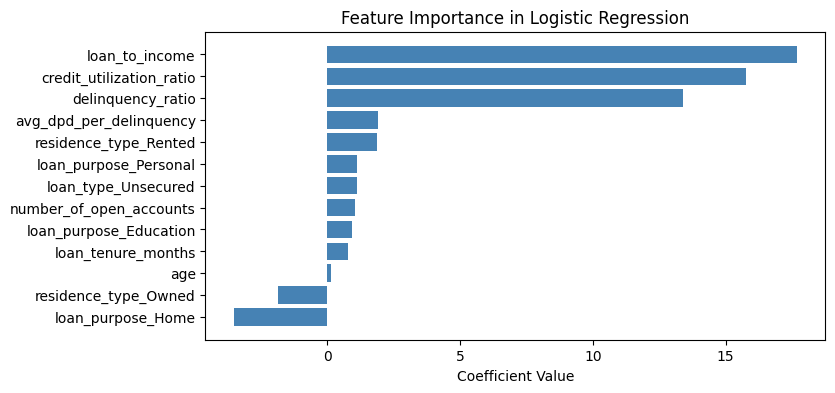

In [93]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

## Save the Model

In [94]:
X_test_encoded.head(2)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
33553,0.3462,0.5283,0.3333,0.1212,0.2580,0.0429,0.9000,True,False,True,False,False,False
9427,0.2885,0.6226,1.0000,0.8586,0.6897,0.0000,0.0000,True,False,False,True,False,False


In [95]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [97]:
col_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='object')

In [98]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [101]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': col_to_scale
}
dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data.joblib']

In [102]:
final_model.coef_, final_model.intercept_

(array([[ 0.14294078,  0.78033286,  1.03042289, 15.7637112 , 17.69563518,
         13.39210508,  1.92649315, -1.85328899,  1.87737987,  0.91552761,
         -3.52648727,  1.12467299,  1.12467299]]),
 array([-20.72713892]))